<h1 align="center">AtliQo Bank Credit Card Launch: Phase 1</h1>

Objective: Analyze customers' transactions and credit profiles to figure out a target group for the launch of AtliQo bank credit card

### Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt 
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [ ]:
### Load Da

In [2]:
df_cust = pd.read_csv("datasets/customers.csv")
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


In [3]:
df_cust.shape

(1000, 8)

In [4]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


### Handle Null_values in customer dataset

In [5]:
# checking  null values in customer dataframe 
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [6]:
# we see that there is 50 null value in annual_income 
df_cust.annual_income.isnull().sum()

np.int64(50)

In [7]:
# now print the null values of annual income 
df_cust.annual_income.isna() # it only return true and false 

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996    False
997    False
998     True
999    False
Name: annual_income, Length: 1000, dtype: bool

In [8]:
# proper way to see the null values in annual income 
df_cust[df_cust.annual_income.isna()]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,NaN,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,NaN,Single
97,98,Virat Puri,Male,47,Suburb,Business Owner,NaN,Married
102,103,Aarav Shah,Male,32,City,Data Scientist,NaN,Married
155,156,Kiaan Saxena,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Verma,Male,52,City,Business Owner,NaN,Single
186,187,Samar Sardar,Male,53,City,Consultant,NaN,Single
192,193,Ishan Joshi,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Advait Mukherjee,Male,48,City,Business Owner,NaN,Married
232,233,Aditya Goel,Male,26,City,Freelancer,NaN,Married


In [9]:
# we find median value but occupation base beacuse different occupation have different medin values now we used pandas group by 
df_cust.groupby("occupation")["annual_income"].mean()

occupation
Accountant              64123.562500
Artist                  45267.685714
Business Owner         264976.866906
Consultant              58989.786517
Data Scientist         135524.215569
Freelancer              76990.479821
Fullstack Developer     78270.225352
Name: annual_income, dtype: float64

In [10]:
occupation_wise_median = df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [11]:
# we used function method to fullfill all null values at a once 
def get_med_val(row):
    if pd.isnull(row["annual_income"]) : 
        return occupation_wise_median[row["occupation"]] 
    else : 
        return row["annual_income"]


In [12]:
# ussing apply function to full filll this 
df_cust["annual_income"] = df_cust.apply( get_med_val , axis=1)

In [13]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [14]:
df_cust.iloc[[14 ,82,2]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,45794.0,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,46759.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married


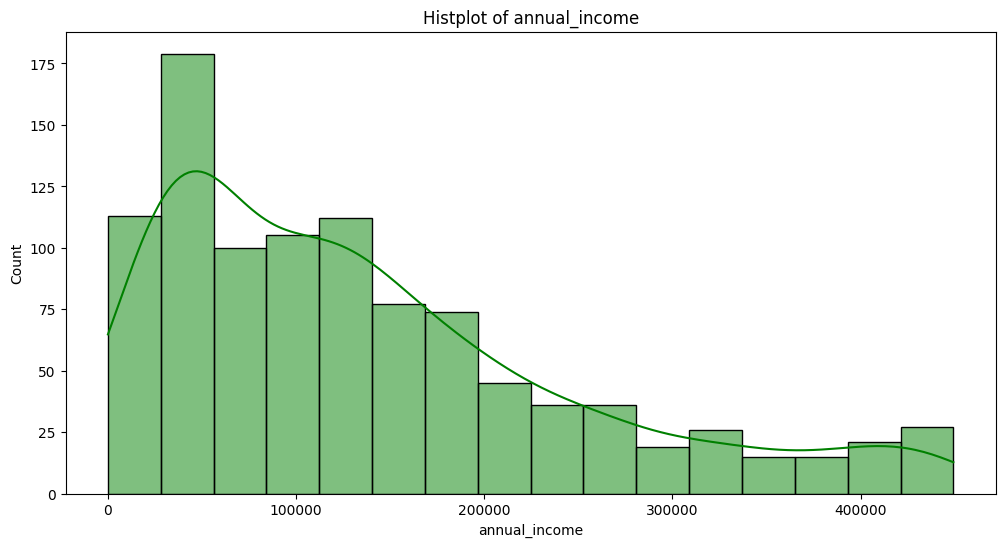

In [15]:
# now we have to plot a histogram of customer datasets 
plt.figure(figsize=(12 , 6))
sns.histplot(df_cust.annual_income , color="green" , kde=True , label='Data')
plt.title("Histplot of annual_income")
plt.show()


### Check and detect the outliers in annual_income 

In [16]:
df_cust.annual_income.describe()

count      1000.000000
mean     138916.765500
std      110969.408643
min           2.000000
25%       48229.500000
50%      113416.000000
75%      192614.000000
max      449346.000000
Name: annual_income, dtype: float64

In [17]:
find_outliers = df_cust[df_cust["annual_income"] < 500 ] 
find_outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,50.0,Married
262,263,Vivaan Tandon,Male,53,Suburb,Business Owner,50.0,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,50.0,Married
333,334,Avani Khanna,Female,29,City,Data Scientist,50.0,Married
340,341,Priya Sinha,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Advait Batra,Male,54,City,Consultant,2.0,Married
592,593,Priya Gandhi,Female,32,City,Business Owner,50.0,Married
633,634,Rudra Mehtani,Male,26,City,Data Scientist,2.0,Married
686,687,Vihaan Jaiswal,Male,40,City,Business Owner,2.0,Married
696,697,Ishan Negi,Male,47,City,Consultant,20.0,Married


In [18]:
# full fill the outliers using function 
def getmed_val(row) :
    if row["annual_income"] < 500:
        return occupation_wise_median[row["occupation"]] 
    else : 
        return row["annual_income"]

In [19]:
df_cust["annual_income"] = df_cust.apply(getmed_val, axis=1)

In [20]:
check_outliers = df_cust[df_cust["annual_income"] < 500 ] 
check_outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


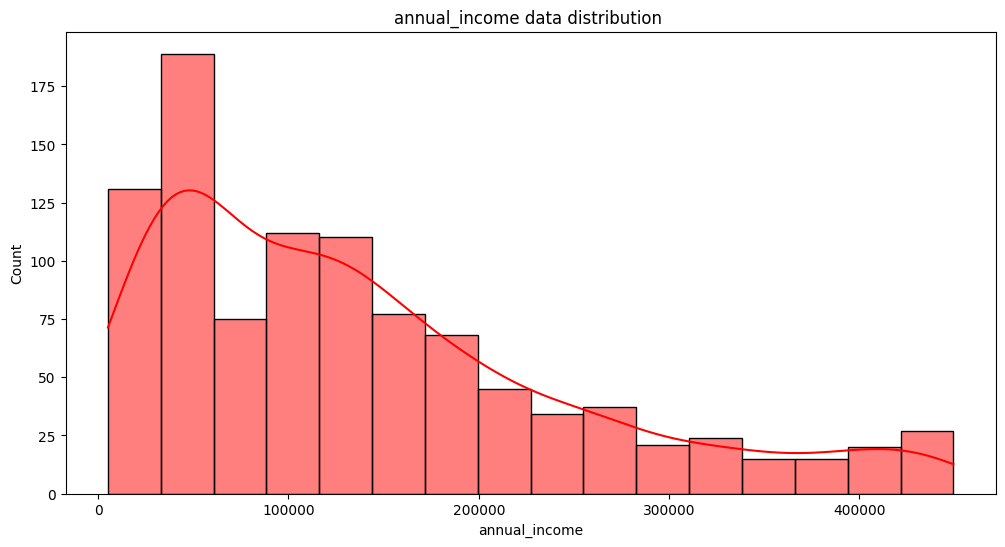

In [21]:
# now plot histogram aftr removing outliers in dataframe 
plt.figure(figsize=(12,6))
sns.histplot(df_cust["annual_income"] , color="red" , kde=True , label='Data')
plt.title("annual_income data distribution ")
plt.show()

### data visualization 

In [22]:
# find occupation wise average 
occupation_wise_mean = df_cust.groupby("occupation")["annual_income"].mean()
occupation_wise_mean

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [23]:
occupation_wise_mean.index

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='object', name='occupation')

In [24]:
occupation_wise_mean.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

C:\Users\123\AppData\Local\Temp\ipykernel_5816\726275541.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occupation_wise_mean.index , y=occupation_wise_mean.values , palette="tab20")


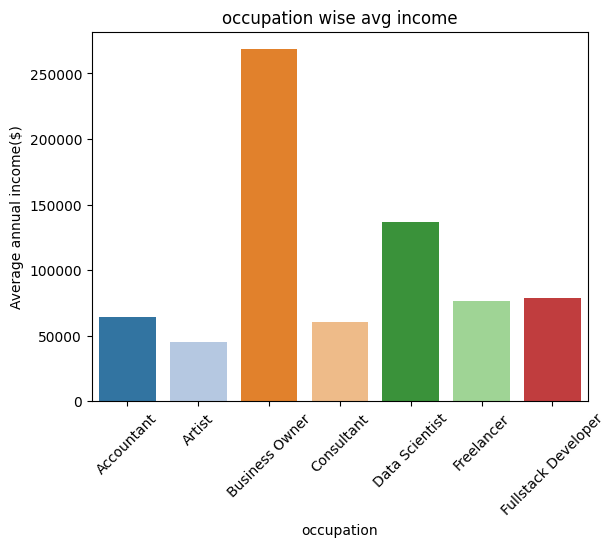

In [25]:
# plot histogram occupation wise mean 
sns.barplot(x=occupation_wise_mean.index , y=occupation_wise_mean.values , palette="tab20")
plt.xticks(rotation=45)
plt.xlabel("occupation")
plt.ylabel("Average annual income($)")
plt.title("occupation wise avg income")
plt.show()

In [26]:
# category wise aannual_income average 
category_columns = ["gender" , "location" , "occupation" , "marital_status"]
category_columns

['gender', 'location', 'occupation', 'marital_status']

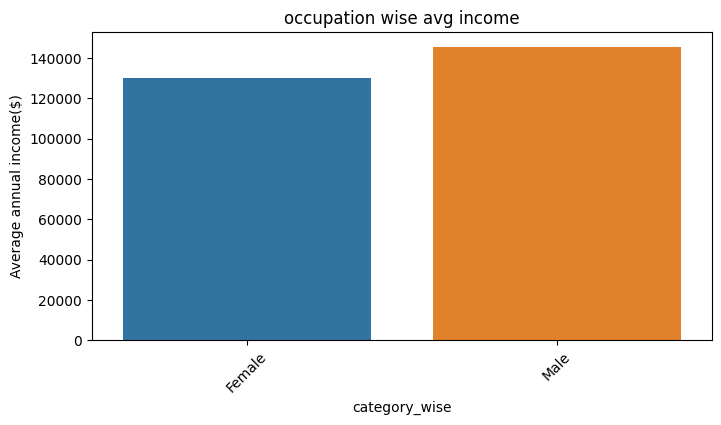

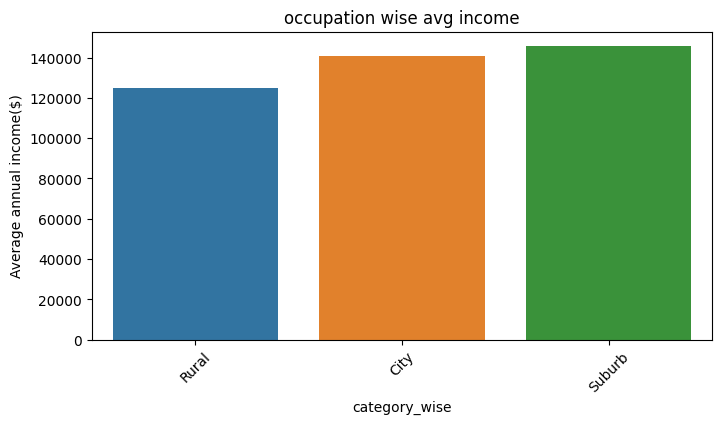

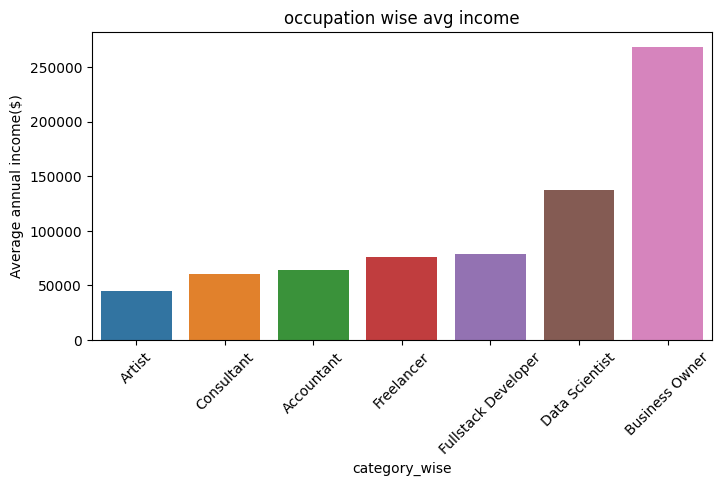

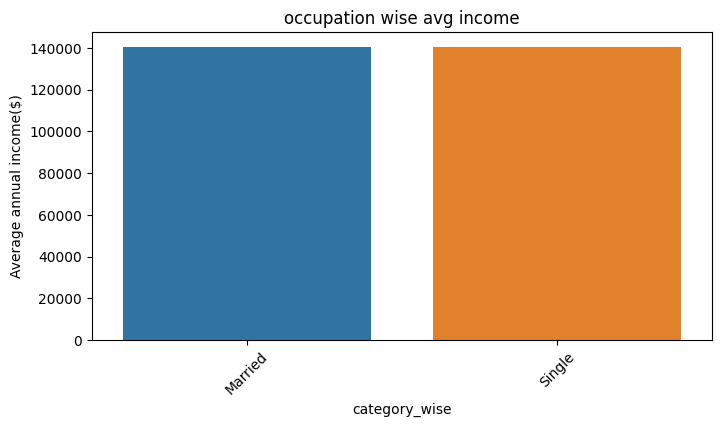

In [27]:
for col in category_columns :
    plt.figure(figsize=(8 , 4))
    occupation_wise_mean = df_cust.groupby(col)["annual_income"].mean().sort_values()
    sns.barplot(
    x=occupation_wise_mean.index,
    y=occupation_wise_mean.values,
    hue=occupation_wise_mean.index,   # add hue
    palette="tab10",
    legend=False )                      # hide extra legend)
    plt.xticks(rotation=45)
    plt.xlabel("category_wise")
    plt.ylabel("Average annual income($)")
    plt.title("occupation wise avg income")
    plt.show()
   



### Treating outliers in age column 

In [28]:
df_cust.age.head()

0     2
1    47
2    21
3    24
4    48
Name: age, dtype: int64

In [29]:
df_cust["age"].describe()

count    1000.000000
mean       36.405000
std        15.666155
min         1.000000
25%        26.000000
50%        32.000000
75%        46.000000
max       135.000000
Name: age, dtype: float64

In [30]:
# occupation waise age 
occupation_wise_age_avg = df_cust.groupby("occupation")["age"].mean()
occupation_wise_age_avg

occupation
Accountant             34.812500
Artist                 28.236842
Business Owner         49.740484
Consultant             45.680412
Data Scientist         33.157609
Freelancer             25.184211
Fullstack Developer    27.878378
Name: age, dtype: float64

In [31]:
detect_outliers = df_cust[(df_cust.age < 18 ) | (df_cust.age > 70 )] 
detect_outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
41,42,Aaryan Shah,Male,110,City,Artist,7621.0,Married
165,166,Sia Dutta,Female,1,City,Freelancer,39721.0,Single
174,175,Rohan Sharma,Male,110,City,Freelancer,23723.0,Married
222,223,Arjun Batra,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Aarav Tandon,Male,110,City,Consultant,96522.0,Single
295,296,Ayush Pandey,Male,1,Rural,Accountant,55254.0,Married
325,326,Virat Goel,Male,110,City,Accountant,61021.0,Single
610,611,Rehan Verma,Male,135,Rural,Business Owner,444776.0,Married
692,693,Dhruv Jha,Male,1,City,Business Owner,83045.0,Married


In [32]:
# remove outliers from age group
def get_mean_val(row):
    if (row["age"] < 18) or (row["age"] > 70):
        return occupation_wise_age_avg[row["occupation"]]
    else:
        return row["age"]

df_cust["age"] = df_cust.apply(get_mean_val, axis=1)

In [33]:
df_cust[(df_cust.age < 18 ) | (df_cust.age > 70 )] 

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


<Axes: xlabel='age', ylabel='Count'>

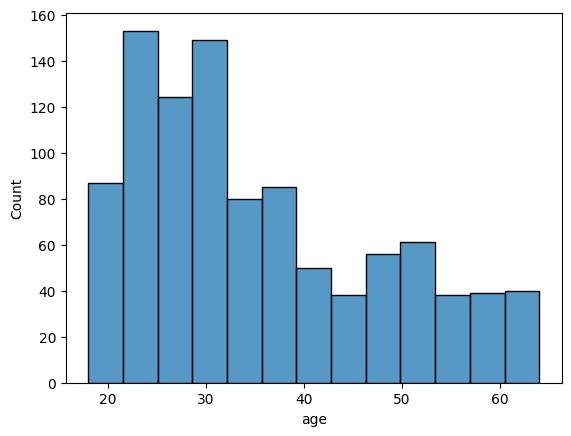

In [34]:
sns.histplot(df_cust["age"] )

### Gender location and age_group distribution 

In [35]:
# use cut function to create new column in datasets 
bins_edges = [17,25,48,65]
bins_lables= ['18-25' , '26-48' , '49-65']
df_cust["age_group"] = pd.cut( df_cust["age"] , bins=bins_edges , labels=bins_lables)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47.000000,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21.000000,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24.000000,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48.000000,City,Consultant,39406.0,Married,26-48


In [36]:
age_group = df_cust.age_group.value_counts(normalize=True)*100
age_group

age_group
26-48    57.3
18-25    24.0
49-65    18.7
Name: proportion, dtype: float64

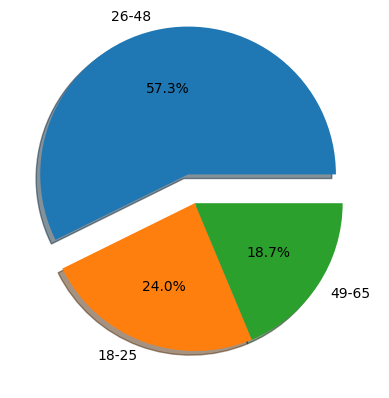

In [37]:
plt.pie(age_group, labels=age_group.index , autopct="%1.1f%%",shadow=True,explode=(0.2,0,0))
plt.show()

In [38]:
df_cust.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [39]:
df_cust_gender_location = df_cust.groupby(["location" , "gender"]).size().unstack()
df_cust_gender_location 

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


<Axes: xlabel='location'>

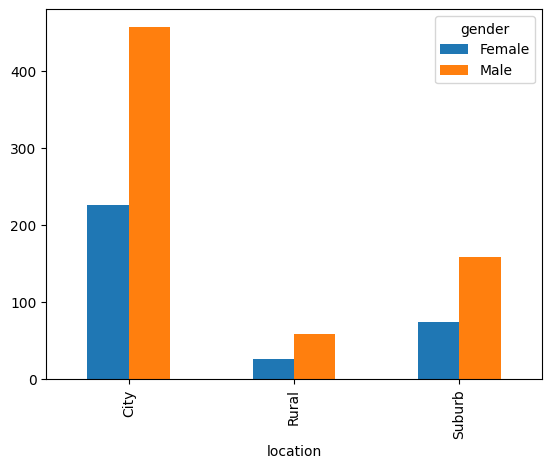

In [40]:
df_cust_gender_location.plot(kind="bar")

### Credit score data_cleaning 

In [41]:
df_credit_score = pd.read_csv("datasets/credit_profiles.csv")
df_credit_score.tail()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
999,996,564,0.702963,688.0,2.0,1250.0
1000,997,774,0.465462,17139.0,0.0,60000.0
1001,998,529,0.585856,386.0,3.0,1000.0
1002,999,725,0.249670,6973.0,2.0,40000.0
1003,1000,775,0.696050,33956.0,1.0,60000.0


In [42]:
df_credit_score.shape

(1004, 6)

In [43]:
df_credit_score.nunique()

cust_id                           1000
credit_score                       419
credit_utilisation                1000
outstanding_debt                   781
credit_inquiries_last_6_months       5
credit_limit                         8
dtype: int64

In [44]:
df_credit_score[df_credit_score["cust_id"].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [45]:
df_cs_clean = df_credit_score.drop_duplicates(subset="cust_id" , keep="last")
df_cs_clean.shape

(1000, 6)

In [46]:
df_cs_clean[df_cs_clean["cust_id"].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [47]:
# find nan value in credit_score 
df_cs_clean.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

In [48]:
df_cs_clean[df_cs_clean["credit_limit"].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [49]:
df_cs_clean.credit_limit.value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

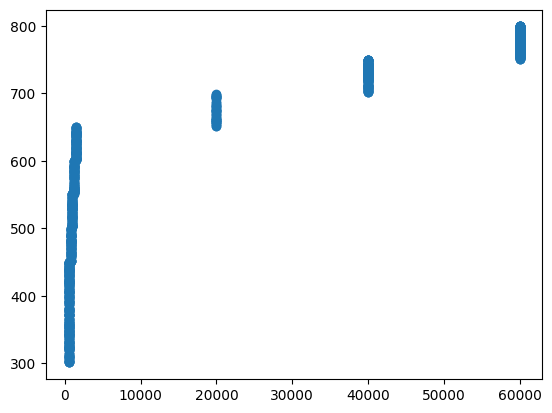

In [50]:
# check corelation between credit_score and credit_limit 
plt.scatter(df_cs_clean.credit_limit , df_cs_clean.credit_score)
plt.show()

In [51]:
df_cs_clean.credit_score.value_counts()

credit_score
736    8
799    8
771    8
781    7
775    7
      ..
416    1
687    1
644    1
745    1
564    1
Name: count, Length: 419, dtype: int64

In [52]:
# setting the range of credit limit 
bins = [300, 400, 500, 600, 700, 800]
labels = ["300-400", "400-500", "500-600", "600-700", "700-800"]
df_cs_clean["credit_score_range"] = pd.cut( df_cs_clean["credit_score"], bins=bins , labels=labels)

C:\Users\123\AppData\Local\Temp\ipykernel_5816\2384791141.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cs_clean["credit_score_range"] = pd.cut( df_cs_clean["credit_score"], bins=bins , labels=labels)


In [53]:
df_cs_clean.sample()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
739,736,483,0.693349,385.0,0.0,750.0,400-500


In [54]:
df_cs_clean_1 = df_cs_clean.copy()
df_cs_clean_1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-800
1,2,587,0.107928,161644.0,2.0,1250.0,500-600
2,3,544,0.854807,513.0,4.0,1000.0,500-600
3,4,504,0.336938,224.0,2.0,1000.0,500-600
4,5,708,0.586151,18090.0,2.0,40000.0,700-800


In [55]:
df_cs_clean_1[df_cs_clean_1["credit_score_range"] == "700-800" ] 

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-800
4,5,708,0.586151,18090.0,2.0,40000.0,700-800
6,7,747,0.523965,15544.0,4.0,40000.0,700-800
16,17,702,0.894423,18444.0,0.0,40000.0,700-800
21,22,785,0.897089,36083.0,3.0,60000.0,700-800
...,...,...,...,...,...,...,...
994,991,709,0.718484,15473.0,4.0,40000.0,700-800
996,993,782,0.477170,20305.0,2.0,60000.0,700-800
1000,997,774,0.465462,17139.0,0.0,60000.0,700-800
1002,999,725,0.249670,6973.0,2.0,40000.0,700-800


In [56]:
mode_df = df_cs_clean_1.groupby("credit_score_range")["credit_limit"].agg(lambda x : x.mode().iloc[0]).reset_index()
mode_df

C:\Users\123\AppData\Local\Temp\ipykernel_5816\4047171003.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_df = df_cs_clean_1.groupby("credit_score_range")["credit_limit"].agg(lambda x : x.mode().iloc[0]).reset_index()


,credit_score_range,credit_limit
0,300-400,500.0
1,400-500,500.0
2,500-600,1000.0
3,600-700,1500.0
4,700-800,60000.0


In [57]:
df_cs_clean_2 = pd.merge(df_cs_clean_1 , mode_df , on = "credit_score_range" , suffixes=("" , "_mode"))
df_cs_clean_2.sample(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
897,899,775,0.487290,21548.0,0.0,NaN,700-800,60000.0
523,524,732,0.478525,12674.0,3.0,40000.0,700-800,60000.0
857,859,770,0.262048,8252.0,0.0,60000.0,700-800,60000.0
875,877,482,0.743564,344.0,2.0,750.0,400-500,500.0
160,161,771,0.725129,27341.0,1.0,60000.0,700-800,60000.0


In [58]:
df_cs_clean_2[df_cs_clean_2.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
819,821,426,0.578425,177.0,3.0,NaN,400-500,500.0
190,191,794,0.340700,16522.0,0.0,NaN,700-800,60000.0
767,769,563,0.865592,898.0,3.0,NaN,500-600,1000.0


In [59]:
df_cs_clean_3 = df_cs_clean_2.copy()
df_cs_clean_3["credit_limit"].fillna(df_cs_clean_3["credit_limit_mode"] , inplace=True)
df_cs_clean_3.head()

C:\Users\123\AppData\Local\Temp\ipykernel_5816\3180365810.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cs_clean_3["credit_limit"].fillna(df_cs_clean_3["credit_limit_mode"] , inplace=True)


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-800,60000.0
1,2,587,0.107928,161644.0,2.0,1250.0,500-600,1000.0
2,3,544,0.854807,513.0,4.0,1000.0,500-600,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-600,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-800,60000.0


In [60]:
df_cs_clean_3[df_cs_clean_3.credit_limit.isnull()].shape

(0, 8)

In [61]:
df_cs_clean_3.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

In [62]:
df_cs_clean_3.loc[[10 , 35]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
10,11,679,0.557450,9187.0,2.0,1500.0,600-700,1500.0
35,36,790,0.112535,4261.0,1.0,60000.0,700-800,60000.0


In [63]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.323323,589.471471,0.498663,9692.948949,1.955956,19952.202202,21879.379379
std,288.910029,152.085696,0.233079,25266.811373,1.414944,24998.344738,28318.962596
min,1.000000,301.000000,0.103761,33.000000,0.000000,500.000000,500.000000
25%,250.500000,460.000000,0.293785,221.000000,1.000000,750.000000,500.000000
50%,500.000000,602.000000,0.487290,551.000000,2.000000,1500.000000,1500.000000
75%,750.500000,738.000000,0.697670,11839.000000,3.000000,40000.000000,60000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000,60000.000000


In [64]:
# we find some outliers in outstanding_debt 
df_cs_clean_3[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"]]	

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,500-600,1000.0
10,11,679,0.557450,9187.0,2.0,1500.0,600-700,1500.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-700,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,700-800,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-800,60000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-800,60000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-400,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-800,60000.0
301,302,722,0.608076,122402.0,4.0,60000.0,700-800,60000.0
330,331,799,0.363420,208898.0,4.0,60000.0,700-800,60000.0


In [65]:
df_cs_clean_3.loc[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"] , "outstanding_debt"] = df_cs_clean_3["credit_limit"]

In [66]:
df_cs_clean_3[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [67]:
df_cs_clean_3.loc[[861]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
861,863,792,0.399555,60000.0,3.0,60000.0,700-800,60000.0


### Find correlation among credit profile variables

In [68]:
# first merge two data frame 
df_merged = pd.merge(df_cust , df_cs_clean_3 , on="cust_id" , how="inner")
df_merged

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700-800,60000.0
1,2,Anjali Pandey,Female,47.000000,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,500-600,1000.0
2,3,Aaryan Chauhan,Male,21.000000,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-600,1000.0
3,4,Rudra Bali,Male,24.000000,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-600,1000.0
4,5,Advait Malik,Male,48.000000,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-800,60000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,996,Manya Vasudeva,Female,26.000000,City,Freelancer,46759.0,Married,26-48,564,0.702963,688.0,2.0,1250.0,500-600,1000.0
995,997,Aarav Dhawan,Male,55.000000,City,Business Owner,290061.0,Single,49-65,774,0.465462,17139.0,0.0,60000.0,700-800,60000.0
996,998,Rehan Jha,Male,29.000000,City,Fullstack Developer,139141.0,Married,26-48,529,0.585856,386.0,3.0,1000.0,500-600,1000.0
997,999,Amara Rathore,Female,47.000000,City,Business Owner,261191.5,Married,26-48,725,0.249670,6973.0,2.0,40000.0,700-800,60000.0


In [69]:
# now show the correlation between credit_score and credit_limit 
df_merged[["credit_score" , "credit_limit" , "age"]].corr()


,credit_score,credit_limit,age
credit_score,1.000000,0.846710,0.447602
credit_limit,0.846710,1.000000,0.512029
age,0.447602,0.512029,1.000000


In [70]:
numeric_cols = [
    "age",
    "annual_income",
    "credit_score",
    "credit_utilisation",
    "outstanding_debt",
    "credit_inquiries_last_6_months",
    "credit_limit"
]
corr_matrix = df_merged[numeric_cols].corr()
corr_matrix 

,age,annual_income,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
age,1.000000,0.619011,0.447602,-0.028578,0.445642,-0.025807,0.512029
annual_income,0.619011,1.000000,0.575794,-0.085740,0.550349,0.002359,0.682560
credit_score,0.447602,0.575794,1.000000,-0.068281,0.673692,-0.002516,0.846710
credit_utilisation,-0.028578,-0.085740,-0.068281,1.000000,0.188699,-0.013134,-0.077757
outstanding_debt,0.445642,0.550349,0.673692,0.188699,1.000000,0.024415,0.807066
credit_inquiries_last_6_months,-0.025807,0.002359,-0.002516,-0.013134,0.024415,1.000000,0.014317
credit_limit,0.512029,0.682560,0.846710,-0.077757,0.807066,0.014317,1.000000


<Axes: >

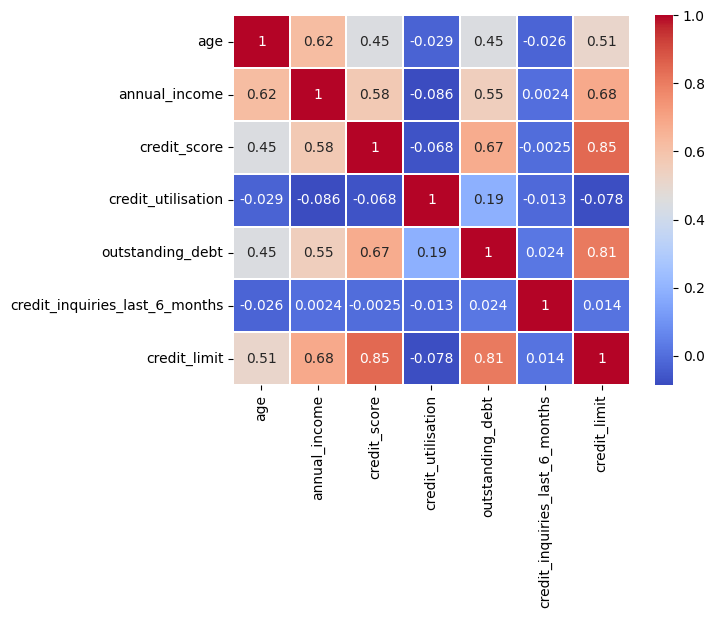

In [71]:
sns.heatmap(corr_matrix , linewidth=0.10 , cmap="coolwarm" , annot=True )

### finding null value in Transaction datasets

In [72]:
df_trans = pd.read_csv("datasets/transactions.csv")
df_trans.sample(3)

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
290835,290836,559,2023-05-25,126,Flipkart,Electronics,Credit Card
116397,116398,896,2023-02-27,78,Shopify,Fashion & Apparel,Credit Card
157006,157007,940,2023-03-19,90,Alibaba,Fashion & Apparel,Credit Card


In [73]:
df_trans.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [74]:
df_trans.shape

(500000, 7)

In [75]:
df_trans[df_trans.platform.isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


In [76]:
df_trans.platform.mode()

0    Amazon
Name: platform, dtype: object

In [77]:
df_trans.platform.value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='product_category'>

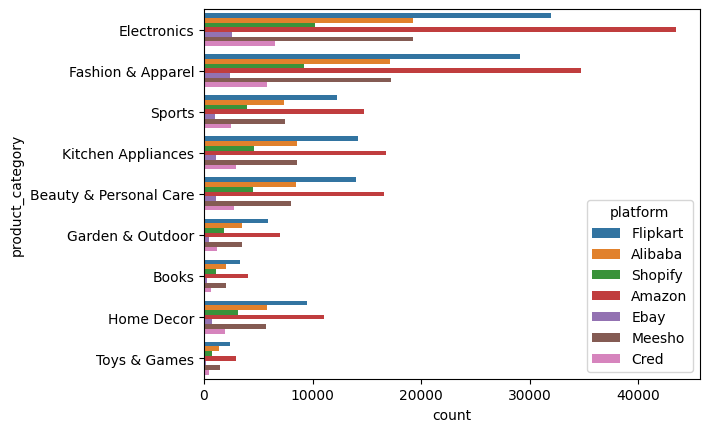

In [78]:
sns.countplot(y="product_category" , hue="platform" , data=df_trans)

In [79]:
df_trans.platform.mode()

0    Amazon
Name: platform, dtype: object

In [80]:
df_trans["platform"].fillna( df_trans.platform.mode()[0] , inplace=True)

C:\Users\123\AppData\Local\Temp\ipykernel_5816\245585240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trans["platform"].fillna( df_trans.platform.mode()[0] , inplace=True)


In [81]:
df_trans[df_trans.platform.isnull()]


,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


### Data cleaning treating outliers using IQR 

In [82]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [83]:
df_trans_zero = df_trans[df_trans.tran_amount == 0 ]
df_trans_zero

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499326,499327,695,2023-09-05,0,Amazon,Electronics,Credit Card
499494,499495,295,2023-09-05,0,Amazon,Electronics,Credit Card
499708,499709,141,2023-09-05,0,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [84]:
df_trans_zero.shape

(4734, 7)

In [85]:
df_trans_zero.product_category.value_counts()

product_category
Electronics    4734
Name: count, dtype: int64

In [86]:
df_trans_zero[["platform" , "product_category" , "payment_type"]].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

In [87]:
df_trans_1 = df_trans[(df_trans.platform =="Amazon") & (df_trans.product_category =="Electronics" ) &  (df_trans.payment_type =="Credit Card" )]
df_trans_1.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card


In [88]:
median_to_replace = df_trans_1[df_trans.tran_amount > 0 ].tran_amount.median()
median_to_replace

C:\Users\123\AppData\Local\Temp\ipykernel_5816\2305500416.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  median_to_replace = df_trans_1[df_trans.tran_amount > 0 ].tran_amount.median()


np.float64(554.0)

In [89]:
df_trans["tran_amount"].replace(0, median_to_replace , inplace=True)

C:\Users\123\AppData\Local\Temp\ipykernel_5816\660536531.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trans["tran_amount"].replace(0, median_to_replace , inplace=True)


In [90]:
df_trans.loc[[120]]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,554,Amazon,Electronics,Credit Card


In [91]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711635,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


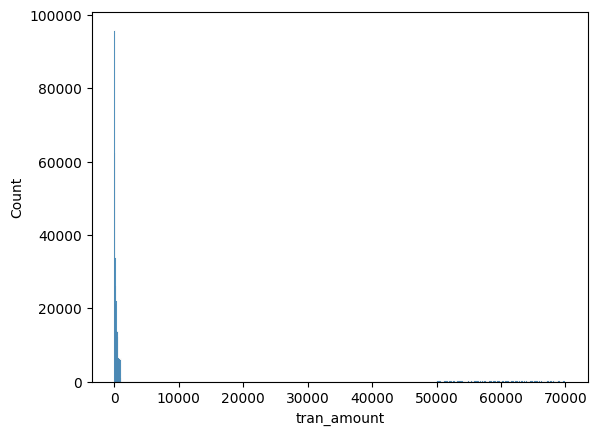

In [92]:
sns.histplot(df_trans.tran_amount)
plt.show()

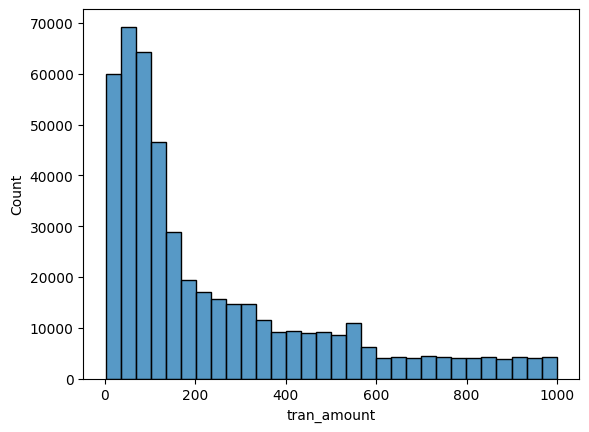

In [93]:
sns.histplot(df_trans[df_trans.tran_amount < 1000].tran_amount , bins=30)
plt.show()

In [94]:
df_trans[df_trans.tran_amount > 6000]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [95]:
Q1 , Q3 = df_trans["tran_amount"].quantile([0.25 , 0.75])
Q1 ,Q3

(66.0, 413.0)

In [96]:
# finding iqr and lower and upper bound 
IQR = Q3 - Q1
IQR 
lower = Q1 - 2 * IQR
upper = Q3 + 2*IQR

lower , upper

(-628.0, 1107.0)

In [97]:
df_trans_outlier = df_trans[df_trans.tran_amount > upper]
df_trans_outlier.shape

(25000, 7)

In [104]:
df_trans_outlier.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card


In [103]:
df_trans_outlier.index

Index([    26,     49,     94,    104,    113,    121,    169,    173,    177,
          179,
       ...
       499661, 499673, 499681, 499711, 499741, 499742, 499888, 499900, 499966,
       499996],
      dtype='int64', length=25000)

In [98]:
df_trans_normal = df_trans[df_trans.tran_amount < upper]
df_trans_normal.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [99]:
replce_with_mean = df_trans_normal.groupby("product_category")["tran_amount"].mean()
replce_with_mean

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [109]:
# replace outliers with category wise mean value 
df_trans.loc[df_trans_outlier.index , "tran_amount"] = df_trans_outlier["product_category"].map(replce_with_mean)

In [110]:
df_trans.loc[df_trans_outlier.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.333298,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.773288,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,64.553463,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,64.553463,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,64.553463,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,269.181631,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,269.181631,Meesho,Sports,Gpay


In [112]:
df_trans.iloc[[26 , 113]]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card


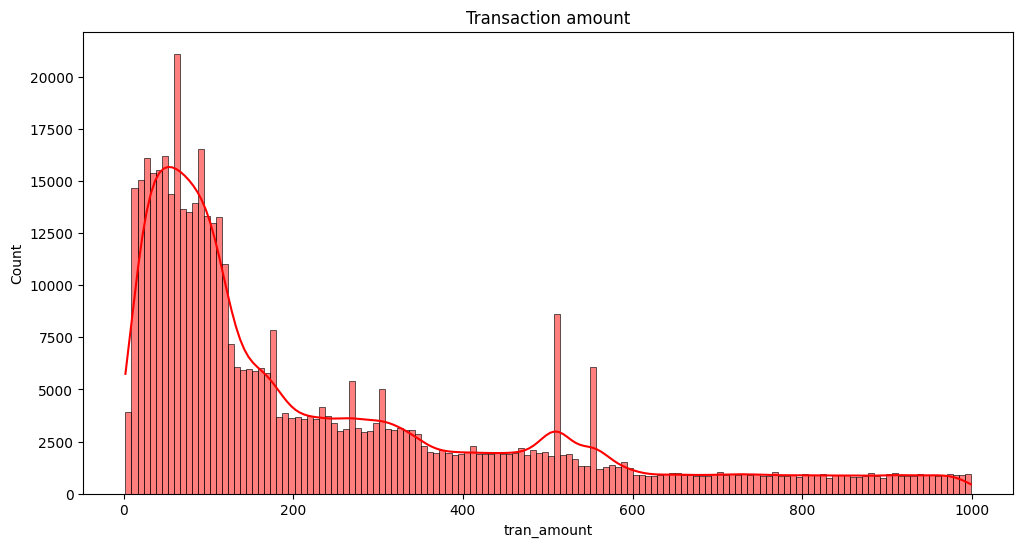

In [119]:
plt.figure(figsize=(12 , 6))
sns.histplot(df_trans.tran_amount , color="red" , kde=True)
plt.title("Transaction amount")
plt.show()


### Data visualization of transaction table

In [121]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking


<Axes: xlabel='payment_type', ylabel='count'>

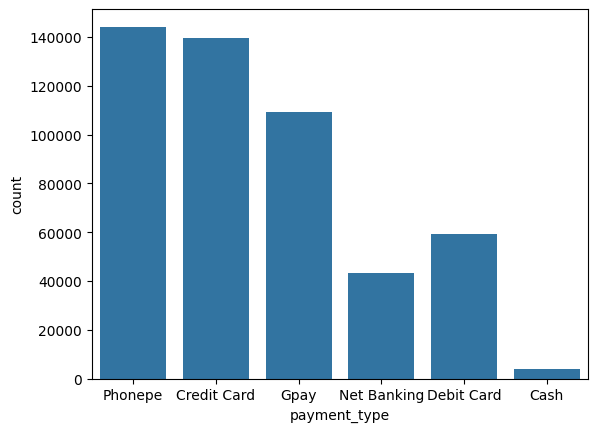

In [122]:
sns.countplot(x=df_trans.payment_type)

In [125]:
# get payment type of different age group 
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47.000000,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21.000000,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24.000000,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48.000000,City,Consultant,39406.0,Married,26-48


In [128]:
df_merged_2 = pd.merge(df_merged , df_trans , on="cust_id" , how="inner")
df_merged_2.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-800,60000.0,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-800,60000.0,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-800,60000.0,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-800,60000.0,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Manya Acharya,Female,49.740484,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-800,60000.0,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


<Axes: xlabel='age_group', ylabel='count'>

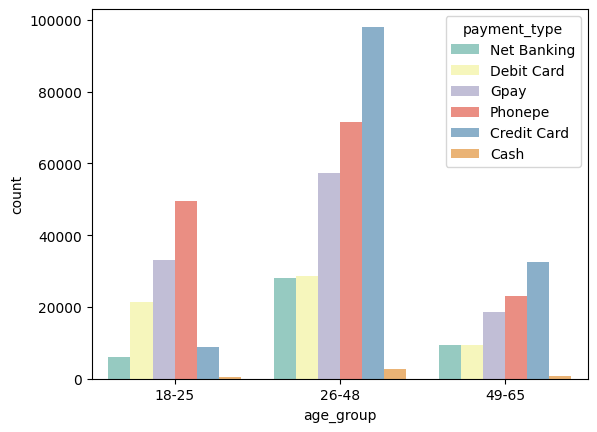

In [135]:
sns.countplot(x="age_group" , hue="payment_type" , data=df_merged_2 , palette="Set3")

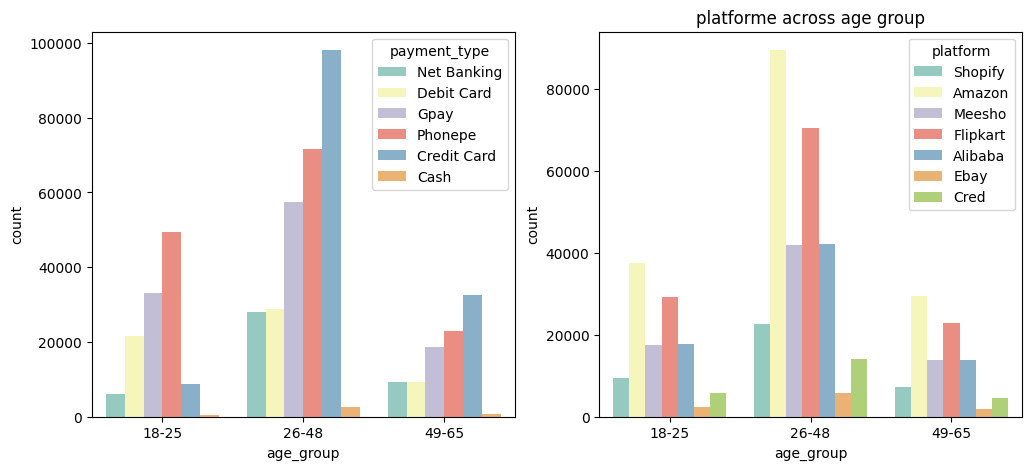

In [206]:
# using subplot to use number of rows and column 
fig , (ax1 , ax2)= plt.subplots(1 , 2  ,figsize=(12,5))
sns.countplot(x="age_group" , hue="payment_type" , data=df_merged_2 , palette="Set3" , ax=ax1)
plt.title("payment_type across age group")


sns.countplot(x="age_group" , hue="platform" , data=df_merged_2 , palette="Set3" , ax=ax2)
plt.title("platforme across age group")
plt.show()


### further analysis on transaction_table

In [219]:
age_group_metrics = df_merged_2.groupby("age_group")[["annual_income" , "credit_score" , "credit_limit"]].mean().reset_index()
age_group_metrics

C:\Users\123\AppData\Local\Temp\ipykernel_5816\2226479435.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_metrics = df_merged_2.groupby("age_group")[["annual_income" , "credit_score" , "credit_limit"]].mean().reset_index()


,age_group,annual_income,credit_score,credit_limit
0,18-25,36374.357756,482.430198,884.165977
1,26-48,145383.126571,598.213950,20782.092553
2,49-65,260430.658253,701.876810,42093.927504


C:\Users\123\AppData\Local\Temp\ipykernel_5816\730286192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
C:\Users\123\AppData\Local\Temp\ipykernel_5816\730286192.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='tab10', ax=ax2)
C:\Users\123\AppData\Local\Temp\ipykernel_5816\730286192.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_score', data=age_group_metri

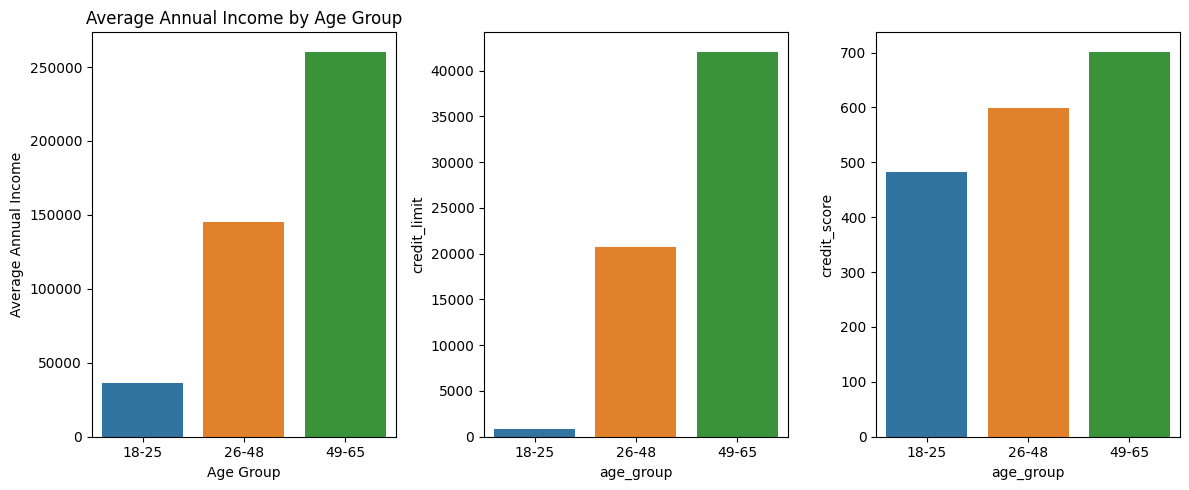

In [221]:
# using subplot to use number of rows and column 
fig , (ax1 , ax2 , ax3) = plt.subplots(1 , 3  ,figsize=(12,5))
#average of annual_income 
# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: credit_limit by age group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='tab10', ax=ax2)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 3: credit_score by age group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='tab10', ax=ax3)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0) 


plt.tight_layout()
plt.show()

<h2 align="center" style="color:purple">Phase 2: AtliQ0 Bank Credit Card Project</h2>

### Business Analysis and launch of AB testing: Targeting Untapped Market

### Insights specific to customers with age group of 18 - 25
1. People with age group of 18 -25 accounts to ~25% of customer base in the data
2. Avg annual income of this age group is less than 50k
3. They don't have much credit history which is getting reflected in their credit score and max credit limit 
4. Usage of credit cards as payment type is relatively low compared to other groups
5. Avg transaction amount made with credit cards is also low compared to other groups
5. Top 3 most used shopping products categories  : Electronics, Fashion & Apparel, Beauty & Personal care

![My Image](image.png)


![My Analysis Graph](analysis.png)


<h1>Pre Campaign</h1>

In [203]:
# determine the person for testing 
alpha = 0.05 
power = 0.8 
effect_size = 0.2 

sms.tt_ind_solve_power(
    effect_size = effect_size ,
    alpha = alpha , 
    power = power ,
    ratio=1 , 
    alternative = "two-sided"
)

393.40569300025135

In [202]:
# different effect size for targeting the people 
alpha = 0.05
power = 0.8

effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 1.0]

for es in effect_sizes:
    sample_size = sms.tt_ind_solve_power(
        effect_size = es,
        alpha = alpha,
        power = power,
        ratio = 1,
        alternative = "two-sided"
    )
    print(f"Effect size {es} → Required sample size: {sample_size:.2f}")


Effect size 0.1 → Required sample size: 1570.73
Effect size 0.2 → Required sample size: 393.41
Effect size 0.3 → Required sample size: 175.38
Effect size 0.4 → Required sample size: 99.08
Effect size 0.5 → Required sample size: 63.77
Effect size 1.0 → Required sample size: 16.71


## (2) Post-Campaign

### Two sample z_test for hyothesis testing

In [163]:
df = pd.read_csv("datasets/avg_transactions_after_campaign.csv")
df.sample(5)

,campaign_date,control_group_avg_tran,test_group_avg_tran
1,2023-09-11,191.27,248.68
8,2023-09-18,265.13,212.60
47,2023-10-27,213.46,231.34
20,2023-09-30,226.08,253.34
45,2023-10-25,205.03,219.20


In [164]:
df.shape

(62, 3)

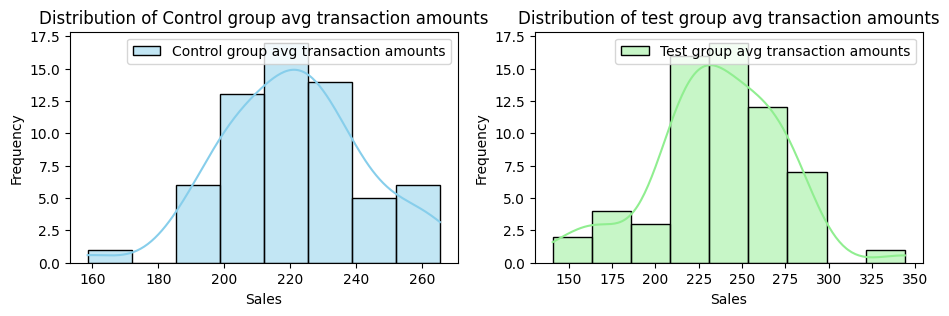

In [192]:
# Let's look at distributions of avg transactions amounts in both groups
# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Plot the distribution of Campaign A Sales
sns.histplot(df['control_group_avg_tran'], kde=True, color='skyblue', label='Control group avg transaction amounts', ax=ax1)
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group avg transaction amounts')
ax1.legend()

# Plot the distribution of Campaign B Sales
sns.histplot(df['test_group_avg_tran'], kde=True, color='lightgreen', label='Test group avg transaction amounts', ax=ax2)
ax2.set_xlabel('Sales')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of test group avg transaction amounts')
ax2.legend()

# Show the plots
plt.show()

In [165]:
# find mean of control _group 
control_mean = df.control_group_avg_tran.mean()
control_std = df.control_group_avg_tran.std()
control_mean , control_std

(np.float64(221.1751612903226), np.float64(21.35919211202701))

In [166]:
# find mean and std of target group 
test_mean = df.test_group_avg_tran.mean()
test_std = df.test_group_avg_tran.std()
test_mean , test_std

(np.float64(235.9835483870968), np.float64(36.658082109186374))

In [185]:
df_shape = df.shape[0]
df_shape

62

In [186]:
# now find the z_score 
a = control_std **2 / df_shape
b = test_std **2 / df_shape
a,b


(np.float64(7.358307865781884), np.float64(21.67443522457823))

In [187]:
z_score = (test_mean - control_mean)/np.sqrt(a+b)
z_score

np.float64(2.748297374569113)

In [178]:
alpha = 0.05

In [180]:
z_critical = stats.norm.ppf(1-alpha)
z_critical

np.float64(1.6448536269514722)

In [188]:
z_score > z_critical 

np.True_

### now we used p_value fr this testing 

In [189]:
p_value = 1-stats.norm.cdf(z_score)
p_value

np.float64(0.0029952824622024865)

In [190]:
alpha

0.05

In [191]:
p_value < alpha

np.True_

### we used ready built in module to find z_test and p_value at a once without doing lot of code 


In [196]:
z_score , p_value = sm.stats.ztest(df["test_group_avg_tran"] , df["control_group_avg_tran"] , alternative="larger")
z_score , p_value

(np.float64(2.7482973745691135), np.float64(0.002995282462202502))